In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [2]:
df = pd.read_csv("UnifiedDataset.csv")

df.head()


,Country,Year,Gender,Life Expectancy,Infant Mortality Rate,Low CI Value Infant Mortality Rate,High CI Value Infant Mortality Rate,Under 5 Mortality Rate,Low CI Value Under 5 Mortality Rate,High CI Value Under 5 Mortality Rate,...,Cereal Consumption Rye,Cereal Consumption Barley,Cereal Consumption Sorghum,Cereal Consumption Maize,Cereal Consumption Wheat,Cereal Consumption Rice,Diet Calories Animal Protein,Diet Calories Plant Protein,Diet Calories Fat,Diet Calories Carbohydrates
0,Afghanistan,1990,Both sexes,50.331,120.4,111.2,130.9,177.7,162.5,194.3,...,NaN,103.0,NaN,201.0,1195.0,174.0,67.80,197.08,435.60,1613.52
1,Afghanistan,1990,Female,51.442,114.2,105.1,124.7,173.1,158.0,189.7,...,NaN,103.0,NaN,201.0,1195.0,174.0,67.80,197.08,435.60,1613.52
2,Afghanistan,1990,Male,49.281,126.2,116.4,137.5,182.0,166.6,199.3,...,NaN,103.0,NaN,201.0,1195.0,174.0,67.80,197.08,435.60,1613.52
3,Afghanistan,1991,Both sexes,50.999,116.8,108.2,126.2,171.7,157.6,186.9,...,NaN,94.0,NaN,164.0,1043.0,159.0,64.96,173.68,370.08,1435.28
4,Afghanistan,1991,Female,52.119,110.7,102.1,120.4,167.1,153.0,182.6,...,NaN,94.0,NaN,164.0,1043.0,159.0,64.96,173.68,370.08,1435.28


In [3]:
df.isnull().sum()


Country                            0
Year                               0
Gender                             0
Life Expectancy                    0
Infant Mortality Rate           4590
                                ... 
Cereal Consumption Rice         7391
Diet Calories Animal Protein    8087
Diet Calories Plant Protein     8087
Diet Calories Fat               8087
Diet Calories Carbohydrates     8087
Length: 150, dtype: int64

In [4]:
# Numerical columns
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical columns
cat_cols = df.select_dtypes(exclude=np.number).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


In [5]:
label_encoder = LabelEncoder()

for col in cat_cols:
    df[col] = label_encoder.fit_transform(df[col])


In [6]:
# Use 'Life Expectancy' as the target variable
X = df.drop("Life Expectancy", axis=1)
y = df["Life Expectancy"]

In [7]:
# Create Health Risk Level from Life Expectancy
def risk_level(le):
    if le < 60:
        return "High"
    elif le < 70:
        return "Medium"
    else:
        return "Low"

df["Health_Risk_Level"] = df["Life Expectancy"].apply(risk_level)


C:\Users\aq450\AppData\Local\Temp\ipykernel_16220\3896570597.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Health_Risk_Level"] = df["Life Expectancy"].apply(risk_level)


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [10]:
rf_model = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)


In [11]:
param_grid = {
    "n_estimators": [100, 150],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}


In [12]:
from sklearn.model_selection import ParameterGrid

print("Total parameter combinations:", len(ParameterGrid(param_grid)))


Total parameter combinations: 24


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

from sklearn.ensemble import RandomForestRegressor

random_search = RandomizedSearchCV(
    estimator = RandomForestRegressor(random_state=42),
    param_distributions= param_grid,
    n_iter=20,          # try 20 instead of all combos
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=4,
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train)



Fitting 3 folds for each of 20 candidates, totalling 60 fits


In [27]:
best_rf_model = random_search.best_estimator_
random_search.best_params_
y_pred = best_rf_model.predict(X_test)

In [30]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


Mean Squared Error: 0.6500806803291347
Mean Absolute Error: 0.45295116907747
R2 Score: 0.993221160907435


In [61]:
from sklearn.metrics import classification_report, confusion_matrix

# Use the same risk_level function as before
def risk_level(le):
	if le < 60:
		return "High"
	elif le < 70:
		return "Medium"
	else:
		return "Low"

# Convert y_test and y_pred to risk levels
y_test_risk = y_test.apply(risk_level)
y_pred_risk = pd.Series(y_pred).apply(risk_level)

print(classification_report(y_test_risk, y_pred_risk))
print("Confusion Matrix:\n", confusion_matrix(y_test_risk, y_pred_risk))



              precision    recall  f1-score   support

        High       0.98      0.96      0.97       848
         Low       0.98      0.98      0.98      2385
      Medium       0.93      0.95      0.94      1177

    accuracy                           0.97      4410
   macro avg       0.96      0.96      0.96      4410
weighted avg       0.97      0.97      0.97      4410

Confusion Matrix:
 [[ 812    0   36]
 [   1 2342   42]
 [  18   42 1117]]


In [52]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_reg.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [57]:
y_pred = rf_reg.predict(X_test)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))  
print("R2 Score:", r2_score(y_test, y_pred))


Mean Squared Error: 0.6500806803291347
Mean Absolute Error: 0.45295116907747
R2 Score: 0.993221160907435


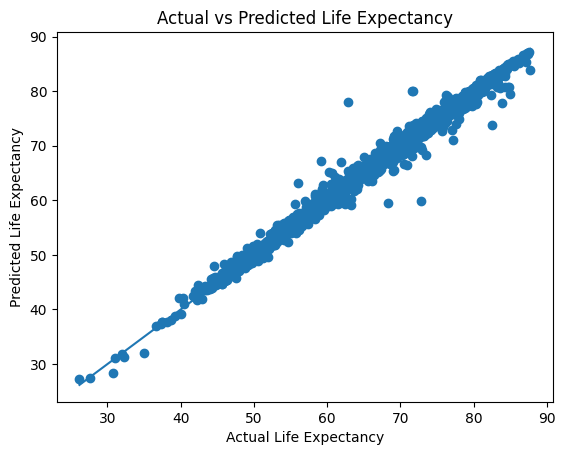

In [58]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)
plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.title("Actual vs Predicted Life Expectancy")
plt.show()


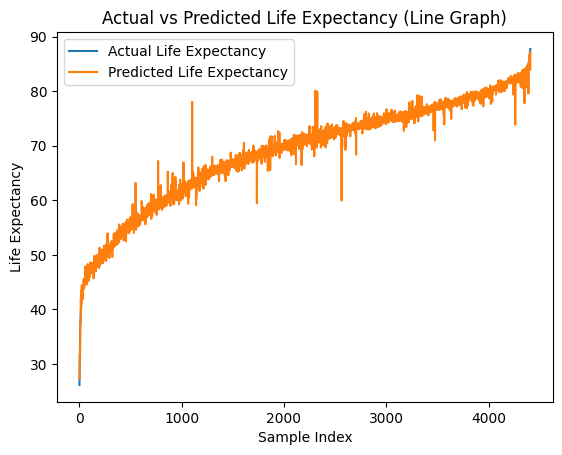

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# Sort values for a clean line graph
sorted_indices = np.argsort(y_test)
y_test_sorted = y_test.iloc[sorted_indices]
y_pred_sorted = y_pred[sorted_indices]

plt.figure()
plt.plot(y_test_sorted.values, label="Actual Life Expectancy")
plt.plot(y_pred_sorted, label="Predicted Life Expectancy")
plt.xlabel("Sample Index")
plt.ylabel("Life Expectancy")
plt.title("Actual vs Predicted Life Expectancy (Line Graph)")
plt.legend()
plt.show()


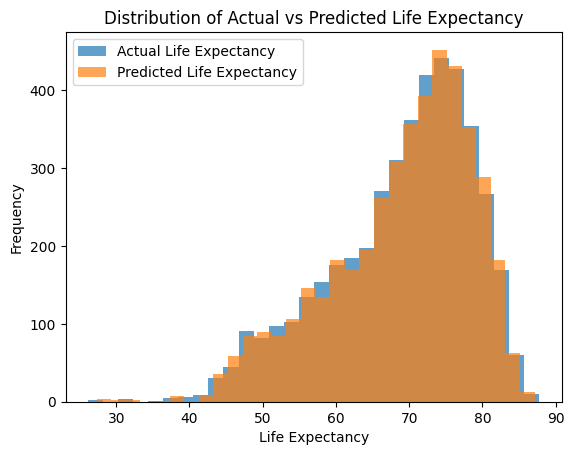

In [60]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(y_test, bins=30, alpha=0.7, label="Actual Life Expectancy")
plt.hist(y_pred, bins=30, alpha=0.7, label="Predicted Life Expectancy")
plt.xlabel("Life Expectancy")
plt.ylabel("Frequency")
plt.title("Distribution of Actual vs Predicted Life Expectancy")
plt.legend()
plt.show()


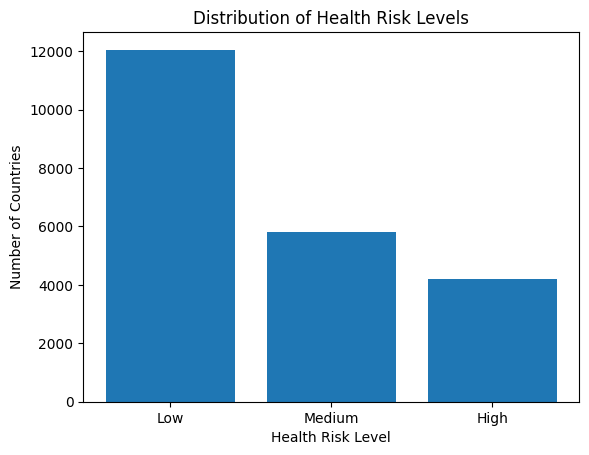

In [63]:

import matplotlib.pyplot as plt

risk_counts = df["Health_Risk_Level"].value_counts()

plt.figure()
plt.bar(risk_counts.index, risk_counts.values)
plt.xlabel("Health Risk Level")
plt.ylabel("Number of Countries")
plt.title("Distribution of Health Risk Levels")
plt.show()


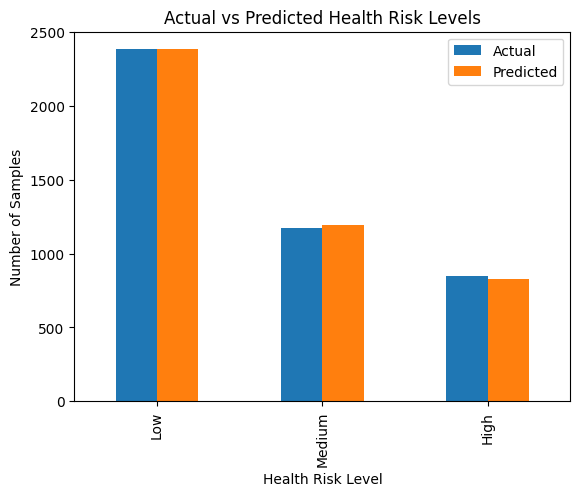

In [66]:
# Convert y_test and y_pred to risk levels
def risk_level(le):
    if le < 60:
        return "High"
    elif le < 70:
        return "Medium"
    else:
        return "Low"

actual_risk = y_test.apply(risk_level)
predicted_risk = pd.Series(y_pred).apply(risk_level)

comparison = pd.DataFrame({
    "Actual": actual_risk.value_counts(),
    "Predicted": predicted_risk.value_counts()
}).fillna(0)

# Ensure the order is Low, Medium, High
comparison = comparison.loc[["Low", "Medium", "High"]]

comparison.plot(kind="bar")
plt.xlabel("Health Risk Level")
plt.ylabel("Number of Samples")
plt.title("Actual vs Predicted Health Risk Levels")
plt.show()